In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
# Fashion-MNIST (28x28) for Autoencoders & CNN tasks
(Xf_train, yf_train), (Xf_test, yf_test) = keras.datasets.fashion_mnist.load_data()

Xf_train = (Xf_train.astype("float32") / 255.0)[..., None]  # (N, 28, 28, 1)
Xf_test  = (Xf_test.astype("float32") / 255.0)[..., None]

print("Train:", Xf_train.shape, "Test:", Xf_test.shape)


Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


In [3]:
def show_reconstructions(x, x_hat, n=10, title="Original vs Reconstructed"):
    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        # original
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: ax.set_title("Original")
        # recon
        ax = plt.subplot(2, n, n+i+1)
        plt.imshow(x_hat[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: ax.set_title("Reconstructed")
    plt.suptitle(title)
    plt.show()


In [4]:
#Task 3-1: Vanilla vs Deep Autoencoder
# Vanilla AE: undercomplete + shallow
latent_dim_vanilla = 64

vanilla_ae = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(latent_dim_vanilla, activation="relu"),
    layers.Dense(28*28, activation="sigmoid"),
    layers.Reshape((28, 28, 1))
])

vanilla_ae.compile(optimizer="adam", loss="mse")
vanilla_ae.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
hist_vanilla = vanilla_ae.fit(
    Xf_train, Xf_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

vanilla_test_mse = vanilla_ae.evaluate(Xf_test, Xf_test, verbose=0)
print("Vanilla AE test MSE:", vanilla_test_mse)


Vanilla AE test MSE: 0.009862176142632961


In [6]:
# Deep AE: deeper encoder/decoder
latent_dim_deep = 32

deep_ae = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(latent_dim_deep, activation="relu"),   # bottleneck
    layers.Dense(128, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(28*28, activation="sigmoid"),
    layers.Reshape((28, 28, 1))
])

deep_ae.compile(optimizer="adam", loss="mse")
deep_ae.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
hist_deep = deep_ae.fit(
    Xf_train, Xf_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

deep_test_mse = deep_ae.evaluate(Xf_test, Xf_test, verbose=0)
print("Deep AE test MSE:", deep_test_mse)


Deep AE test MSE: 0.010947398841381073


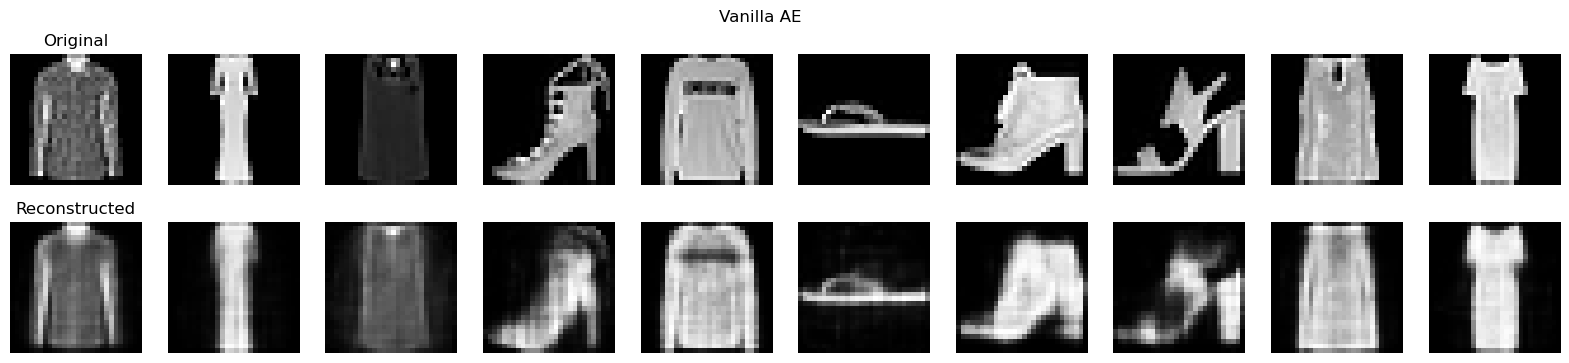

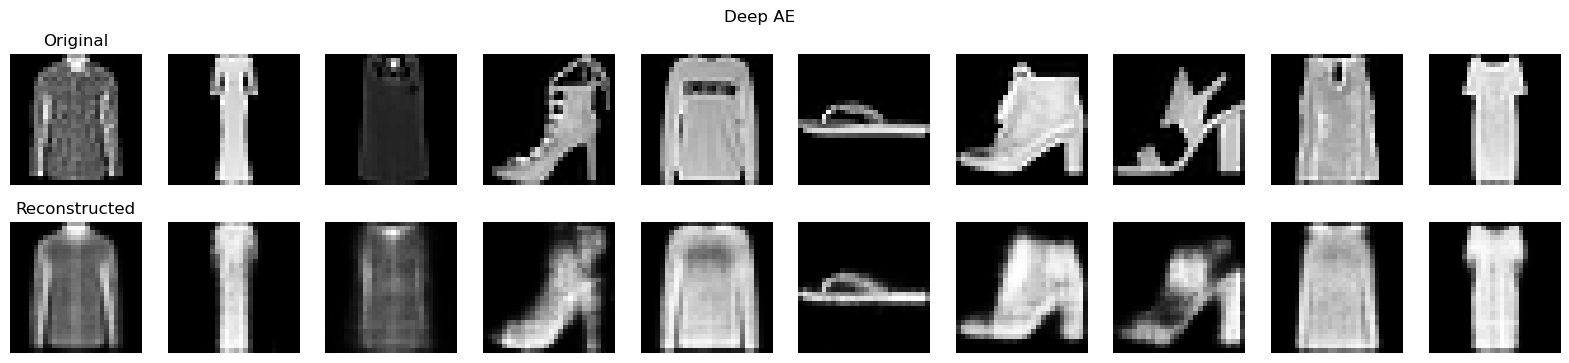

In [8]:
idx = np.random.choice(len(Xf_test), size=10, replace=False)
x_sample = Xf_test[idx]

x_hat_v = vanilla_ae.predict(x_sample, verbose=0)
x_hat_d = deep_ae.predict(x_sample, verbose=0)

show_reconstructions(x_sample, x_hat_v, n=10, title="Vanilla AE")
show_reconstructions(x_sample, x_hat_d, n=10, title="Deep AE")


In [9]:
task3_1_table = pd.DataFrame({
    "Model": ["Vanilla Dense AE", "Deep Dense AE"],
    "Latent dim": [latent_dim_vanilla, latent_dim_deep],
    "Epochs": [15, 20],
    "Test MSE": [vanilla_test_mse, deep_test_mse]
})
task3_1_table


,Model,Latent dim,Epochs,Test MSE
0,Vanilla Dense AE,64,15,0.009862
1,Deep Dense AE,32,20,0.010947


In [10]:
#Task 3-2: CNN variants + dropout + BN + augmentation (Fashion-MNIST)
# CNN classification uses labels
num_classes = 10

Yf_train = yf_train
Yf_test  = yf_test


In [11]:
def build_cnn(model_type="baseline"):
    model = keras.Sequential()
    model.add(keras.Input(shape=(28, 28, 1)))

    if model_type == "baseline":
        model.add(layers.Conv2D(32, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Conv2D(64, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation="relu"))
        model.add(layers.Dense(10, activation="softmax"))

    elif model_type == "dropout":
        model.add(layers.Conv2D(32, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.25))
        model.add(layers.Conv2D(64, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.25))
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation="relu"))
        model.add(layers.Dropout(0.5))
        model.add(layers.Dense(10, activation="softmax"))

    elif model_type == "bn_dropout":
        model.add(layers.Conv2D(32, 3, padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.25))

        model.add(layers.Conv2D(64, 3, padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.25))

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation="relu"))
        model.add(layers.Dropout(0.5))
        model.add(layers.Dense(10, activation="softmax"))

    return model


def train_eval_cnn(model, X_train, y_train, X_test, y_test, epochs=8, batch_size=128, use_aug=False):
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    if use_aug:
        aug = keras.Sequential([
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.05)
        ])
        X_train_in = aug(X_train, training=True)
        history = model.fit(X_train_in, y_train, epochs=epochs,
                            batch_size=batch_size, validation_split=0.2, verbose=0)
    else:
        history = model.fit(X_train, y_train, epochs=epochs,
                            batch_size=batch_size, validation_split=0.2, verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return history, test_loss, test_acc


In [12]:
cnn_runs = []

# 1) baseline
m1 = build_cnn("baseline")
h1, l1, a1 = train_eval_cnn(m1, Xf_train, Yf_train, Xf_test, Yf_test, epochs=8, use_aug=False)
cnn_runs.append(["baseline", "no", "no", 8, l1, a1])

# 2) dropout
m2 = build_cnn("dropout")
h2, l2, a2 = train_eval_cnn(m2, Xf_train, Yf_train, Xf_test, Yf_test, epochs=10, use_aug=False)
cnn_runs.append(["dropout", "yes", "no", 10, l2, a2])

# 3) BN+dropout + augmentation
m3 = build_cnn("bn_dropout")
h3, l3, a3 = train_eval_cnn(m3, Xf_train, Yf_train, Xf_test, Yf_test, epochs=10, use_aug=True)
cnn_runs.append(["bn+dropout", "yes", "yes", 10, l3, a3])

task3_2_table = pd.DataFrame(cnn_runs, columns=["CNN type", "Dropout", "Augmentation", "Epochs", "Test loss", "Test acc"])
task3_2_table.sort_values("Test acc", ascending=False)


,CNN type,Dropout,Augmentation,Epochs,Test loss,Test acc
1,dropout,yes,no,10,0.276912,0.8999
0,baseline,no,no,8,0.299244,0.8917
2,bn+dropout,yes,yes,10,0.363578,0.8696


In [13]:
#Task 3-3: CIFAR-10 CNN (tutorial-style) + variants
(Xc_train, yc_train), (Xc_test, yc_test) = keras.datasets.cifar10.load_data()
Xc_train = Xc_train.astype("float32") / 255.0
Xc_test  = Xc_test.astype("float32") / 255.0
yc_train = yc_train.squeeze()
yc_test  = yc_test.squeeze()

print("CIFAR-10:", Xc_train.shape, Xc_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 86s 1us/step
CIFAR-10: (50000, 32, 32, 3) (10000, 32, 32, 3)


In [14]:
def build_cifar_cnn(variant="tutorial"):
    model = keras.Sequential()
    model.add(keras.Input(shape=(32, 32, 3)))

    if variant == "tutorial":
        model.add(layers.Conv2D(32, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Conv2D(64, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Conv2D(64, 3, activation="relu"))
        model.add(layers.Flatten())
        model.add(layers.Dense(64, activation="relu"))
        model.add(layers.Dense(10, activation="softmax"))

    elif variant == "dropout":
        model.add(layers.Conv2D(32, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.25))
        model.add(layers.Conv2D(64, 3, activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.25))
        model.add(layers.Conv2D(64, 3, activation="relu"))
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation="relu"))
        model.add(layers.Dropout(0.5))
        model.add(layers.Dense(10, activation="softmax"))

    elif variant == "bn":
        model.add(layers.Conv2D(32, 3, padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D())

        model.add(layers.Conv2D(64, 3, padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D())

        model.add(layers.Conv2D(64, 3, padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation="relu"))
        model.add(layers.Dense(10, activation="softmax"))

    return model


def train_eval_cifar(model, epochs=8, batch_size=128):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(Xc_train, yc_train, validation_split=0.2, epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(Xc_test, yc_test, verbose=0)
    return test_loss, test_acc

cifar_runs = []
for variant, epochs in [("tutorial", 8), ("dropout", 10), ("bn", 10)]:
    m = build_cifar_cnn(variant)
    tl, ta = train_eval_cifar(m, epochs=epochs)
    cifar_runs.append([variant, epochs, tl, ta])

task3_3_table = pd.DataFrame(cifar_runs, columns=["Variant", "Epochs", "Test loss", "Test acc"])
task3_3_table.sort_values("Test acc", ascending=False)


,Variant,Epochs,Test loss,Test acc
1,dropout,10,0.900397,0.6804
0,tutorial,8,1.013119,0.6518
2,bn,10,1.551930,0.6234


In [15]:
#Task 3-4 (Extra): Sparse + Denoising Autoencoders
# Sparse AE: encourages sparse activations in bottleneck
latent_dim_sparse = 128  # overcomplete example (try also 32)

sparse_ae = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(latent_dim_sparse, activation="relu",
                 activity_regularizer=regularizers.l1(1e-5)),
    layers.Dense(256, activation="relu"),
    layers.Dense(28*28, activation="sigmoid"),
    layers.Reshape((28, 28, 1))
])

sparse_ae.compile(optimizer="adam", loss="mse")

hist_sparse = sparse_ae.fit(
    Xf_train, Xf_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

sparse_test_mse = sparse_ae.evaluate(Xf_test, Xf_test, verbose=0)
print("Sparse AE test MSE:", sparse_test_mse)


Sparse AE test MSE: 0.02493865229189396


In [16]:
# Denoising AE: train on noisy inputs, reconstruct clean targets
noise_std = 0.25

def add_noise(x, std=noise_std):
    x_noisy = x + std * np.random.randn(*x.shape).astype("float32")
    return np.clip(x_noisy, 0.0, 1.0)

Xf_train_noisy = add_noise(Xf_train)
Xf_test_noisy  = add_noise(Xf_test)

denoise_ae = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(28*28, activation="sigmoid"),
    layers.Reshape((28, 28, 1))
])

denoise_ae.compile(optimizer="adam", loss="mse")

hist_denoise = denoise_ae.fit(
    Xf_train_noisy, Xf_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

denoise_test_mse = denoise_ae.evaluate(Xf_test_noisy, Xf_test, verbose=0)
print("Denoising AE test MSE (noisy->clean):", denoise_test_mse)


Denoising AE test MSE (noisy->clean): 0.012708766385912895


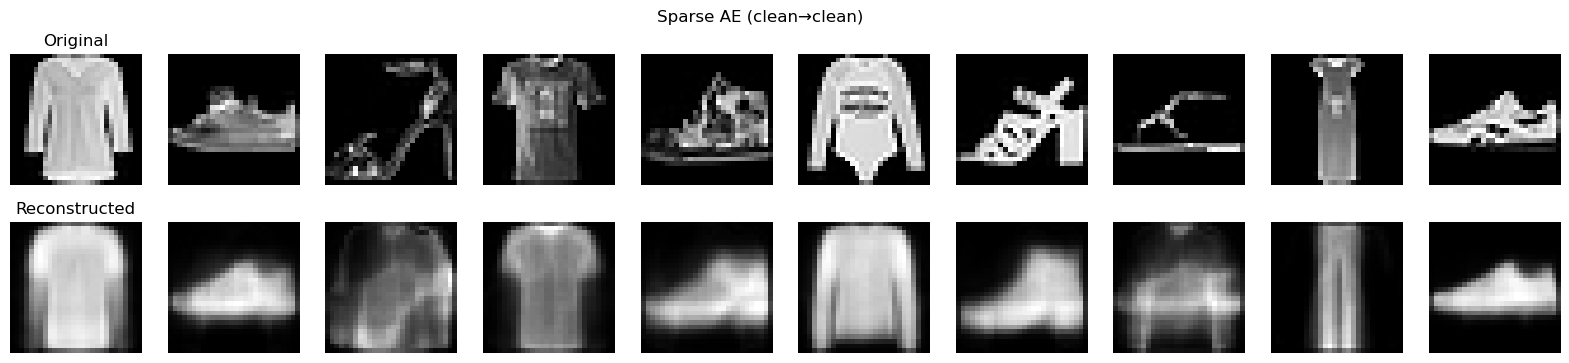

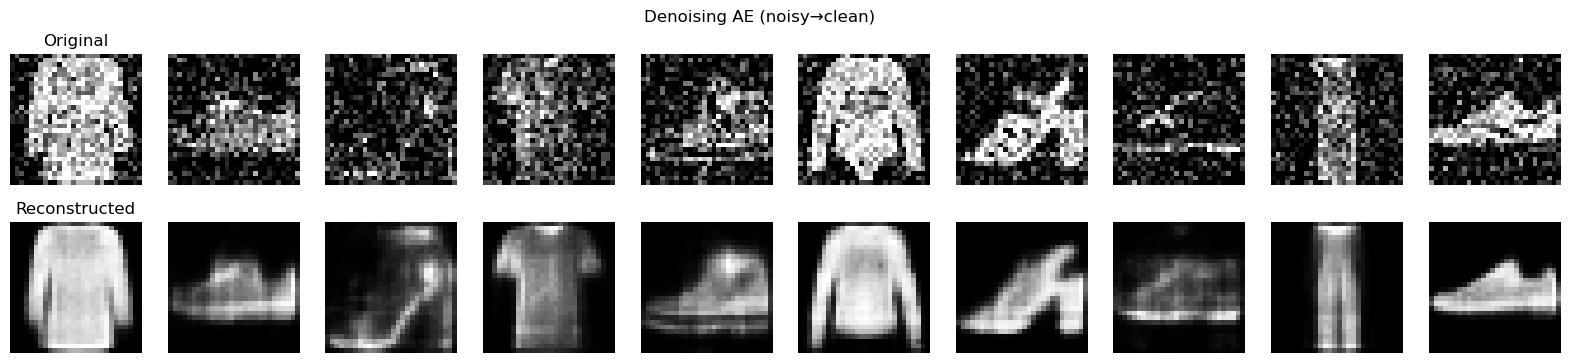

In [17]:
idx = np.random.choice(len(Xf_test), size=10, replace=False)
x_clean = Xf_test[idx]
x_noisy = Xf_test_noisy[idx]

x_hat_sparse = sparse_ae.predict(x_clean, verbose=0)
x_hat_denoise = denoise_ae.predict(x_noisy, verbose=0)

show_reconstructions(x_clean, x_hat_sparse, n=10, title="Sparse AE (clean→clean)")
show_reconstructions(x_noisy, x_hat_denoise, n=10, title="Denoising AE (noisy→clean)")


In [18]:
task3_4_table = pd.DataFrame({
    "Model": ["Sparse AE", "Denoising AE"],
    "Notes": [f"L1 activity reg, latent={latent_dim_sparse}", f"noise_std={noise_std}"],
    "Epochs": [15, 15],
    "Test MSE": [sparse_test_mse, denoise_test_mse]
})
task3_4_table


,Model,Notes,Epochs,Test MSE
0,Sparse AE,"L1 activity reg, latent=128",15,0.024939
1,Denoising AE,noise_std=0.25,15,0.012709


In [19]:
#Task 3-5 (Extra): CNN Autoencoder vs Deep Dense AE
# CNN AE: conv encoder + conv decoder
cnn_ae = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2, padding="same"),   # 14x14
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2, padding="same"),   # 7x7

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.UpSampling2D(2),                   # 14x14
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.UpSampling2D(2),                   # 28x28
    layers.Conv2D(1, 3, activation="sigmoid", padding="same")
])

cnn_ae.compile(optimizer="adam", loss="mse")

hist_cnn_ae = cnn_ae.fit(
    Xf_train, Xf_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

cnn_ae_test_mse = cnn_ae.evaluate(Xf_test, Xf_test, verbose=0)
print("CNN AE test MSE:", cnn_ae_test_mse)


CNN AE test MSE: 0.0036614136770367622


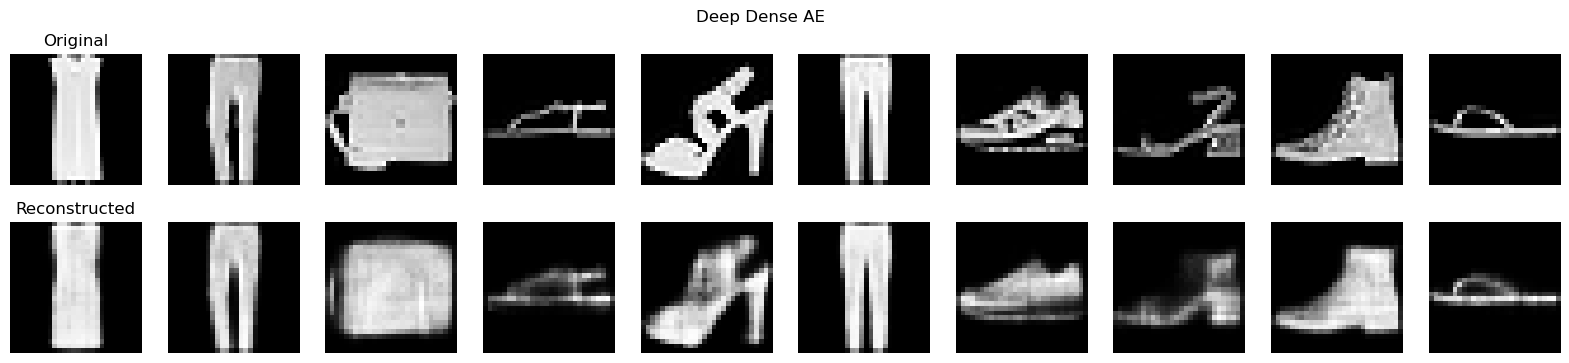

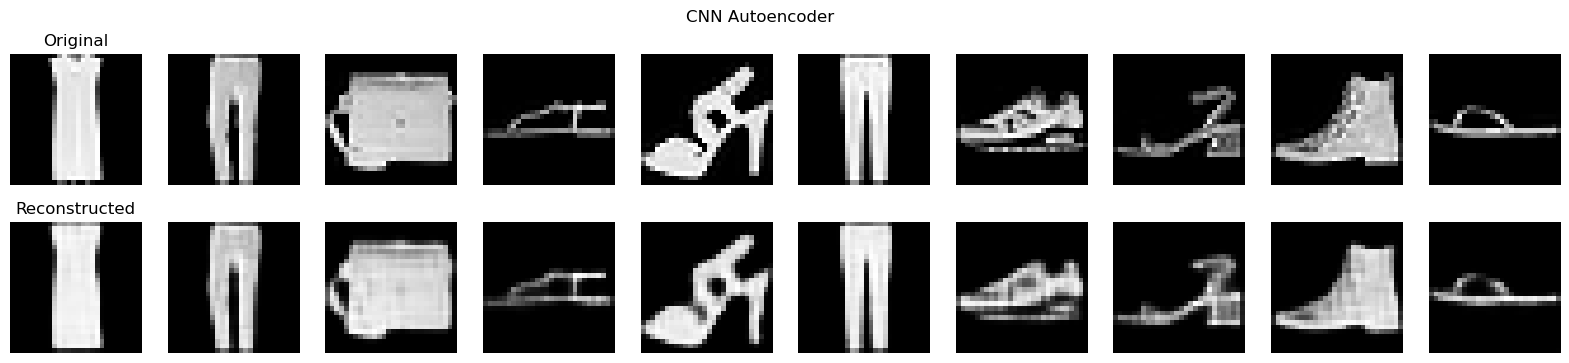

In [20]:
idx = np.random.choice(len(Xf_test), size=10, replace=False)
x_sample = Xf_test[idx]

x_hat_dense = deep_ae.predict(x_sample, verbose=0)   # from Task 3-1
x_hat_cnn   = cnn_ae.predict(x_sample, verbose=0)

show_reconstructions(x_sample, x_hat_dense, n=10, title="Deep Dense AE")
show_reconstructions(x_sample, x_hat_cnn,   n=10, title="CNN Autoencoder")


In [21]:
task3_5_table = pd.DataFrame({
    "Model": ["Deep Dense AE", "CNN AE"],
    "Epochs": [20, 15],
    "Test MSE": [deep_test_mse, cnn_ae_test_mse]
})
task3_5_table


,Model,Epochs,Test MSE
0,Deep Dense AE,20,0.010947
1,CNN AE,15,0.003661


In [22]:
print("=== Task 3-1 ===")
display(task3_1_table)

print("\n=== Task 3-2 ===")
display(task3_2_table.sort_values("Test acc", ascending=False))

print("\n=== Task 3-3 ===")
display(task3_3_table.sort_values("Test acc", ascending=False))

print("\n=== Task 3-4 (Extra) ===")
display(task3_4_table)

print("\n=== Task 3-5 (Extra) ===")
display(task3_5_table)


=== Task 3-1 ===


,Model,Latent dim,Epochs,Test MSE
0,Vanilla Dense AE,64,15,0.009862
1,Deep Dense AE,32,20,0.010947



=== Task 3-2 ===


,CNN type,Dropout,Augmentation,Epochs,Test loss,Test acc
1,dropout,yes,no,10,0.276912,0.8999
0,baseline,no,no,8,0.299244,0.8917
2,bn+dropout,yes,yes,10,0.363578,0.8696



=== Task 3-3 ===


,Variant,Epochs,Test loss,Test acc
1,dropout,10,0.900397,0.6804
0,tutorial,8,1.013119,0.6518
2,bn,10,1.551930,0.6234



=== Task 3-4 (Extra) ===


,Model,Notes,Epochs,Test MSE
0,Sparse AE,"L1 activity reg, latent=128",15,0.024939
1,Denoising AE,noise_std=0.25,15,0.012709



=== Task 3-5 (Extra) ===


,Model,Epochs,Test MSE
0,Deep Dense AE,20,0.010947
1,CNN AE,15,0.003661
